In [54]:
#| echo: false

# import image module
from IPython.display import Image

# get the image
Image(url="./images/data_cleaning.webp",width=450, height=250)



Real-world data is rarely clean and ready for analysis. Data scientists often spend **60-80% of their time** on data preprocessing, with data cleaning being a critical first step that directly impacts the quality of insights and model performance.

This chapter focuses on essential **data cleaning techniques** - identifying and addressing issues in raw data quality that can compromise your analysis.


## Common Data Quality Issues

| **Issue Type** | **Example** | **Impact** | **Solution** |
|----------------|-------------|------------|--------------|
| **Missing values** | `NaN` in "income" column | Reduces sample size, biases results | Impute or drop strategically |
| **Duplicates** | Multiple identical rows | Inflates counts, skews statistics | Identify and remove |
| **Inconsistent types** | `'1'`, `1.0`, `1` for same value | Causes errors in operations | Standardize data types |
| **Outliers** | Salary = $1,000,000,000 | Distorts means, regression lines | Cap, transform, or remove |

</br>

> **Note:** We previously covered handling inconsistent data types (e.g., converting strings to datetime for time-based feature engineering). This chapter focuses on the other three major issues.

Let's first import necessary libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import seaborn as sns

sns.set(font_scale=1.5)

%matplotlib inline


## Handling Missing Data

Missing values in a dataset can occur for several reasons:

- **Equipment failure** - Breakdown of measuring equipment
- **Human error** - Accidental deletion or failure to record observations
- **Non-response** - Survey respondents skip questions
- **Data entry mistakes** - Errors made by researchers or data collectors

### Dataset Introduction

For this chapter, we'll use two related datasets:

- **`GDP_missing_data.csv`** - Contains artificially introduced missing values
- **`GDP_complete_data.csv`** - The complete dataset without missing values

We'll use the complete dataset later to evaluate the accuracy of our imputation methods by comparing imputed values against actual values.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import seaborn as sns

sns.set(font_scale=1.5)

%matplotlib inline

In [6]:
gdp_missing_values_data = pd.read_csv('./Datasets/GDP_missing_data.csv')
gdp_complete_data = pd.read_csv('./Datasets/GDP_complete_data.csv')

In [7]:
gdp_missing_values_data.head()

,economicActivityFemale,country,lifeMale,infantMortality,gdpPerCapita,economicActivityMale,illiteracyMale,illiteracyFemale,lifeFemale,geographic_location,contraception,continent
0,7.2,Afghanistan,45.0,154.0,2474.0,87.5,NaN,85.0,46.0,Southern Asia,NaN,Asia
1,7.8,Algeria,67.5,44.0,11433.0,76.4,26.1,51.0,70.3,Northern Africa,NaN,Africa
2,41.3,Argentina,69.6,22.0,NaN,76.2,3.8,3.8,76.8,South America,NaN,South America
3,52.0,Armenia,67.2,25.0,13638.0,65.0,NaN,0.5,74.0,Western Asia,NaN,Asia
4,53.8,Australia,NaN,6.0,54891.0,NaN,1.0,1.0,81.2,Oceania,NaN,Oceania


Observe that the `gdp_missing_values_data` dataset consists of some missing values shown as NaN (Not a Number).

### Identifying missing values in a dataframe

There are multiple ways to identify missing values in a dataframe

#### `describe()` Method

Note that the descriptive statistics methods associated with Pandas objects ignore missing values by default. Consider the summary statistics of `gdp_missing_values_data`:

In [8]:
gdp_missing_values_data.describe()

,economicActivityFemale,lifeMale,infantMortality,gdpPerCapita,economicActivityMale,illiteracyMale,illiteracyFemale,lifeFemale,contraception
count,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,84.000000
mean,45.935172,65.491724,37.158621,24193.482759,76.563448,13.570028,21.448897,70.615862,51.773810
std,16.875922,9.099256,34.465699,22748.764444,7.854730,16.497954,25.497045,9.923791,31.930026
min,1.900000,36.000000,3.000000,772.000000,51.200000,0.000000,0.000000,39.100000,0.000000
25%,35.500000,62.900000,10.000000,6837.000000,72.000000,1.000000,2.300000,67.500000,17.000000
50%,47.600000,67.800000,24.000000,15184.000000,77.300000,6.600000,9.720000,73.900000,65.000000
75%,55.900000,72.400000,54.000000,35957.000000,81.600000,19.500000,30.200000,78.100000,77.000000
max,90.600000,77.400000,169.000000,122740.000000,93.000000,70.500000,90.800000,82.900000,79.000000


Observe that the `count` statistics report the number of non-missing values of each column in the data, as the number of rows in the data (see code below) is more than the number of non-missing values of all the variables in the above table. Similarly, for the rest of the statistics, such as `mean`, `std`, etc., the missing values are ignored.

In [9]:
#The dataset gdp_missing_values_data has 155 rows
gdp_missing_values_data.shape[0]

155

#### `info()` Method

Shows the count of non-null entries in each column, helping you quickly identify columns with missing values.

In [10]:
gdp_missing_values_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   economicActivityFemale  145 non-null    float64
 1   country                 155 non-null    object 
 2   lifeMale                145 non-null    float64
 3   infantMortality         145 non-null    float64
 4   gdpPerCapita            145 non-null    float64
 5   economicActivityMale    145 non-null    float64
 6   illiteracyMale          145 non-null    float64
 7   illiteracyFemale        145 non-null    float64
 8   lifeFemale              145 non-null    float64
 9   geographic_location     155 non-null    object 
 10  contraception           84 non-null     float64
 11  continent               155 non-null    object 
dtypes: float64(9), object(3)
memory usage: 14.7+ KB


#### `isnull()` Method

This is one of the most direct methods. Using [`df.isnull()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html) returns a DataFrame of Boolean values where `True` indicates a missing value. To get a summary, you can use `df.isnull().sum()` to see the count of missing values in each column.

For finding the number of missing values in each column of `gdp_missing_values_data`, we will sum up the missing values in each column of the dataset:

In [11]:
gdp_missing_values_data.isnull().sum()

economicActivityFemale    10
country                    0
lifeMale                  10
infantMortality           10
gdpPerCapita              10
economicActivityMale      10
illiteracyMale            10
illiteracyFemale          10
lifeFemale                10
geographic_location        0
contraception             71
continent                  0
dtype: int64

### Types of Missing Values

In data science, missing values typically fall into three main types, each requiring different handling strategies:

####  Missing Completely at Random (MCAR)
- **Definition**: Missing values are entirely independent of any variables in the dataset.
- **Example**: A respondent accidentally skips a question on a survey.
- **Impact**: MCAR data can usually be ignored or imputed without biasing the analysis.
- **Handling**: Simple imputation methods, like filling with mean or median values, are often appropriate.

#### Missing at Random (MAR)
- **Definition**: The likelihood of a value being missing is related to other observed variables but not to the missing data itself.
- **Example**: People with higher incomes may be less likely to report their spending, but income data itself is not missing.
- **Impact**: Ignoring MAR values may bias results, so careful imputation based on related variables is recommended.
- **Handling**: More complex imputation methods, like conditional mean imputation or predictive modeling, are suitable.

#### Missing Not at Random (MNAR)
- **Definition**: The probability of missingness is related to the missing data itself, meaning the value is systematically missing.
- **Example**: Patients with severe health conditions might be less likely to report their health status, or students with low scores may be less likely to submit their grades.
- **Impact**: MNAR is the most challenging type, as missing values may introduce significant bias.
- **Handling**: Solutions often include sensitivity analysis, data augmentation, or modeling techniques that account for the missing mechanism, though sometimes domain-specific approaches are necessary.

Understanding the type of missing data helps in selecting the right imputation method and mitigating potential biases in the analysis.


#### Questions

##### 
Why can we ignore observations with missing values without risking skewing the analysis or trends in the case of **Missing Completely at Random (MCAR)**?

#####
Why could ignoring missing values lead to biased results for **Missing at Random (MAR)** and **Missing Not at Random (MNAR)** data?


##### 
For the datset consisting of GDP per capita, think of hypothetical scenarios in which the missing values of GDP per capita can correspond to **MCAR / MAR / MNAR**.

### Methods for Handling Missing Values

#### Removing Missing Values

* **Row/Column Removal** — use [`df.dropna()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html)  
  * **When to use:** If the missing values are few or the affected rows/columns are not critical.  
  * **Risk:** May reduce the dataset’s size, potentially removing useful information.

Let’s drop all rows that contain any missing value from `gdp_missing_values_data`.

In [12]:
gdp_no_missing_data = gdp_missing_values_data.dropna()

By default, `df.dropna()` will drop any row that contains at least one missing value, keeping only the rows that are completely free of missing values.

In [13]:
#Shape of gdp_no_missing_data
gdp_no_missing_data.shape

(42, 12)

#### Limitations of Using `dropna()` Directly

Using `df.dropna()` to remove rows with missing values can sometimes lead to a **significant reduction in data**, which can be problematic if much of the data is valuable and non-missing.  

##### Example

* **Impact of Default Behavior**:  
  Dropping rows with even a single missing value reduced the number of rows from **155 to 42**!  
  This drastic reduction occurs because, by default, `dropna()` removes any row containing at least one missing value, keeping only rows that are completely complete.

* **Loss of Non-Missing Data**:  
  Even if some columns have only a few missing values (e.g., at most 10), using `dropna()` without modification causes all non-missing data in those rows to be lost.  
  This is usually a poor choice—valuable, non-missing data may be removed unnecessarily.

#### Adjusting `dropna()` Behavior

To avoid losing too much data, you can modify how `dropna()` operates using its parameters:

* **`how` parameter**
  - Controls the criteria for dropping rows or columns.
  - `how='any'` *(default)*: Drops a row or column if **any** value is missing.  
  - `how='all'`: Drops a row or column **only if all** values are missing.

* **`thresh` parameter**
  - Specifies the minimum number of **non-missing** values required to retain a row or column.  
  - Useful when you want to keep rows or columns that are mostly complete, even if a few values are missing.

If only a few values in a column are missing, we can often estimate them using the remaining data to **maximize the information** retained in the dataset. However, if most of a column’s values are missing, it becomes much more difficult to reliably estimate or impute those values.

In [14]:
# Calculate percentage of missing values per column
missing_percent = gdp_missing_values_data.isna().mean() * 100

# Display results sorted by percentage (optional)
missing_percent.sort_values(ascending=False)


contraception             45.806452
economicActivityFemale     6.451613
lifeMale                   6.451613
infantMortality            6.451613
gdpPerCapita               6.451613
economicActivityMale       6.451613
illiteracyMale             6.451613
illiteracyFemale           6.451613
lifeFemale                 6.451613
country                    0.000000
geographic_location        0.000000
continent                  0.000000
dtype: float64

In this dataset, about **50% of the values** in the `contraception` column are missing. Therefore, we’ll drop this column, since imputing it would be unreliable given the limited number of non-missing observations.

In [15]:
#Deleting column with missing values in almost half of the observations
gdp_missing_values_data.drop(['contraception'],axis=1,inplace=True)
gdp_missing_values_data.head()

,economicActivityFemale,country,lifeMale,infantMortality,gdpPerCapita,economicActivityMale,illiteracyMale,illiteracyFemale,lifeFemale,geographic_location,continent
0,7.2,Afghanistan,45.0,154.0,2474.0,87.5,NaN,85.0,46.0,Southern Asia,Asia
1,7.8,Algeria,67.5,44.0,11433.0,76.4,26.1,51.0,70.3,Northern Africa,Africa
2,41.3,Argentina,69.6,22.0,NaN,76.2,3.8,3.8,76.8,South America,South America
3,52.0,Armenia,67.2,25.0,13638.0,65.0,NaN,0.5,74.0,Western Asia,Asia
4,53.8,Australia,NaN,6.0,54891.0,NaN,1.0,1.0,81.2,Oceania,Oceania


For the remaining columns, only about **6% of the values** are missing. In this case, instead of dropping rows or columns, it’s often better to **impute** (i.e., fill in) the missing values using the available data.  

Let’s explore several methods for imputing missing values and how they can help us preserve as much information as possible from the dataset.

### Imputing Missing Values

There are many ways to impute missing values, ranging from simple replacements to complex model-based techniques. Some common approaches are described in the [Pandas documentation](https://pandas.pydata.org/pandas-docs/stable/user_guide/missing_data.html).

The **best imputation strategy** depends on the **mechanism of missingness**:

* **MCAR (Missing Completely at Random)** — Simple methods (e.g., mean or median imputation) are generally acceptable.  
* **MAR (Missing at Random)** — Imputation should account for relationships among variables, such as using conditional means or regression-based methods.  
* **MNAR (Missing Not at Random)** — Imputation is challenging and often requires domain expertise to avoid introducing bias.

#### Evaluation Approach

We will apply several imputation techniques to `gdp_missing_values_data` and evaluate their effectiveness by:

1. Comparing imputed `gdpPerCapita` values against actual values from `gdp_complete_data`
2. Computing the **Root Mean Square Error (RMSE)** for each method
3. Visualizing the relationship between imputed and actual values

First, let's define a helper function to visualize and evaluate our imputation results:

In [16]:
# Index of rows with missing values for GDP per capita
null_ind_gdpPC = gdp_missing_values_data.index[gdp_missing_values_data.gdpPerCapita.isnull()]

# Define a function to plot and evaluate imputed values vs actual values 
def plot_actual_vs_predicted(y, title_suffix=""):
    """
    Plot imputed vs actual GDP per capita values and display RMSE.
    
    Parameters:
    - y: DataFrame with imputed gdpPerCapita values
    - title_suffix: Optional string to add to the plot (e.g., method name)
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Extract actual and imputed values
    x = gdp_complete_data.loc[null_ind_gdpPC, 'gdpPerCapita']
    y_imputed = y.loc[null_ind_gdpPC, 'gdpPerCapita']
    
    # Create scatter plot
    ax.scatter(x, y_imputed, alpha=0.6, s=50)
    
    # Add perfect prediction line (45-degree line)
    ax.plot(x, x, color='orange', linewidth=2, label='Perfect imputation')
    
    # Labels and formatting
    ax.set_xlabel('Actual GDP per capita', fontsize=14)
    ax.set_ylabel('Imputed GDP per capita', fontsize=14)
    ax.xaxis.set_major_formatter('${x:,.0f}')
    ax.yaxis.set_major_formatter('${x:,.0f}')
    ax.tick_params(labelsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    
    # Calculate and display RMSE
    rmse = np.sqrt(np.mean((y_imputed - x)**2))
    
    # Position text dynamically based on data range
    x_pos = x.min() + (x.max() - x.min()) * 0.05
    y_pos = y_imputed.max() - (y_imputed.max() - y_imputed.min()) * 0.1
    ax.text(x_pos, y_pos, f'RMSE = ${rmse:,.2f}', 
            fontsize=13, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    return rmse

#### Method 1: Mean/Median Imputation

**Simple imputation** replaces missing values with a statistical measure of central tendency from the non-missing values in the same column.

* **Mean imputation** — Best for normally distributed data without outliers (MCAR scenarios)
* **Median imputation** — Better for skewed data or when outliers are present
* **Mode imputation** — Appropriate for categorical variables

**Advantages:**
- Simple and fast to implement
- Works well for MCAR data

**Disadvantages:**
- Reduces variance in the data
- Ignores relationships between variables
- May introduce bias for MAR or MNAR data

Let's impute missing `gdpPerCapita` values using the mean of non-missing values:

In [17]:
# Extracting the columns with missing values
columns_with_missing = [col for col in gdp_missing_values_data.columns if gdp_missing_values_data[col].isnull().any()]
columns_with_missing

['economicActivityFemale',
 'lifeMale',
 'infantMortality',
 'gdpPerCapita',
 'economicActivityMale',
 'illiteracyMale',
 'illiteracyFemale',
 'lifeFemale']

In [18]:
# Imputing missing values using the mean
gdp_imputed_data_mean = gdp_missing_values_data[columns_with_missing].fillna(gdp_missing_values_data[columns_with_missing].mean())

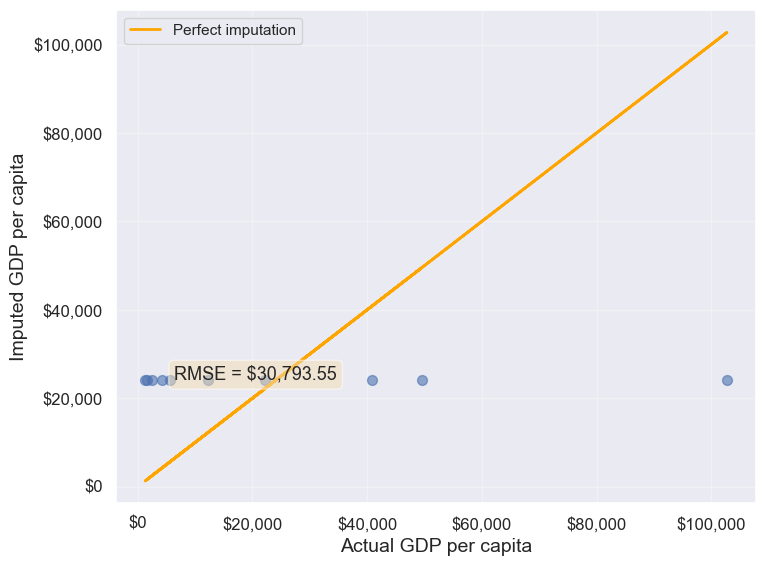

30793.549983587087

In [19]:
plot_actual_vs_predicted(gdp_imputed_data_mean)

**Observation:** The RMSE value indicates how well the mean imputation performed. 

**Note on data types:**
- **Numerical data**: Use mean or median
- **Categorical data**: Use mode (the most frequently occurring value)

Since all columns with missing values in this dataset are numerical, mean imputation is appropriate. For categorical columns, you would use `fillna(df['column'].mode()[0])`.

#### Method 2: Conditional Imputation

**Conditional imputation** uses relationships between variables to predict missing values more accurately than simple mean/median imputation. This approach is better suited for **MAR (Missing at Random)** data.

We'll explore three conditional imputation techniques:

##### A. Group-based Imputation (Conditional Mean)

**Idea**: Impute missing values using the mean of a **subgroup** rather than the overall mean.

If categorical variables show distinct patterns (e.g., GDP varies significantly by continent), we can impute missing values using the mean of the corresponding group. This is more accurate than using the global mean because it accounts for systematic differences between groups.

Let us visualize the distribution of GDP per capita for different continents.

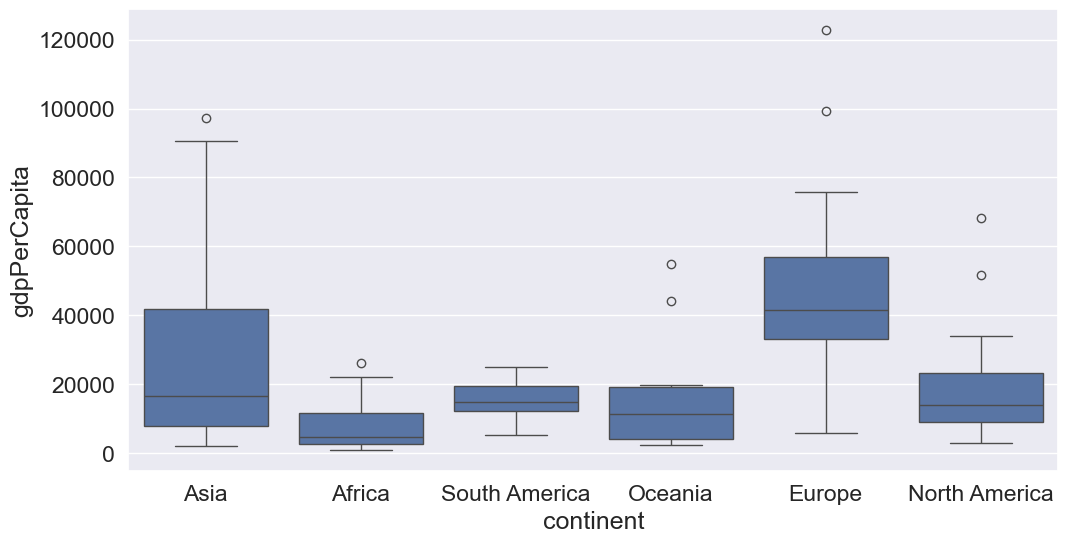

In [20]:
plt.rcParams["figure.figsize"] = (12,6)
sns.boxplot(x = 'continent',y='gdpPerCapita',data = gdp_missing_values_data);

We observe that there is a distinct difference between the GDPs per capita of some of the contents. Let us impute the missing GDP per capita of a country as the mean GDP per capita of the corresponding continent. This imputation should be better than imputing the missing GDP per capita as the mean of all the non-missing values, as the GDP per capita of a country is likely to be closer to the mean GDP per capita of the continent, rather the mean GDP per capita of the whole world.

In [21]:
#Finding the mean GDP per capita of the continent - please defer the understanding of this code to chapter 9.
avg_gdpPerCapita = gdp_missing_values_data['gdpPerCapita'].groupby(gdp_missing_values_data['continent']).mean()
avg_gdpPerCapita

continent
Africa            7638.178571
Asia             25922.750000
Europe           45455.303030
North America    19625.210526
Oceania          15385.857143
South America    15360.909091
Name: gdpPerCapita, dtype: float64

In [22]:
#Creating a copy of missing data to impute missing values
gdp_imputed_data_group_mean = gdp_missing_values_data.copy()

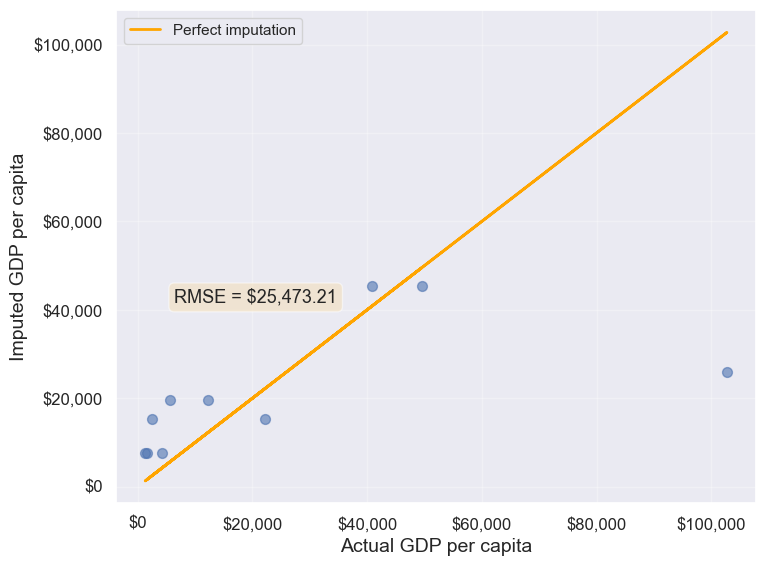

25473.20645170116

In [23]:
#Replacing missing GDP per capita with the mean GDP per capita for the corresponding continent

gdp_imputed_data_group_mean.gdpPerCapita = \
gdp_imputed_data_group_mean['gdpPerCapita'].fillna(gdp_imputed_data_group_mean['continent'].map(avg_gdpPerCapita))
plot_actual_vs_predicted(gdp_imputed_data_group_mean)

Note that the imputed values are closer to the actual values, and the RMSE has further reduced as expected.

Suppose we wish to impute the missing values of each numeric column with the average of the non-missing values of the respective column corresponding to the continent of the observation. The above logic can be extended to each column as shown in the code below.

In [24]:
all_columns_imputed_data = gdp_missing_values_data.iloc[:,[0,2,3,4,5,6,7,8]].apply(lambda x:\
x.fillna(gdp_imputed_data_group_mean['continent'].map(x.groupby(gdp_missing_values_data['continent']).mean())))

##### B. Regression-based Imputation

**Idea**: Use **linear regression** to predict missing values based on their relationship with other variables.

If a variable is highly correlated with another variable in the dataset, we can build a regression model to predict missing values. This method leverages the statistical relationship between variables.

In [25]:
#Let us identify the variable highly correlated with GDP per capita.
gdp_missing_values_data.select_dtypes(include='number').corrwith(gdp_missing_values_data.gdpPerCapita)

economicActivityFemale    0.078332
lifeMale                  0.579850
infantMortality          -0.572201
gdpPerCapita              1.000000
economicActivityMale     -0.134108
illiteracyMale           -0.479143
illiteracyFemale         -0.448273
lifeFemale                0.615954
dtype: float64

In [26]:
#The variable *lifeFemale* has the strongest correlation with GDP per capita. Let us use it to impute missing values of GDP per capita.

#  Extract the variables lifeFemale and GDP per capita
x = gdp_missing_values_data.lifeFemale
y = gdp_missing_values_data.gdpPerCapita

#  Identify non-missing indices
idx_non_missing = np.isfinite(x) & np.isfinite(y)

# Fit a linear regression model (degree=1) to predict GDP per capita given lifeFemale
slope_intercept_trendline = np.polyfit(x[idx_non_missing],y[idx_non_missing],1)   #Finding the slope and intercept for the trendline
compute_y_given_x = np.poly1d(slope_intercept_trendline)

#Creating a copy of missing data to impute missing values
gdp_imputed_data_lr = gdp_missing_values_data.copy()

#Imputing missing values of GDP per capita using the linear regression model
gdp_imputed_data_lr.loc[null_ind_gdpPC,'gdpPerCapita']=compute_y_given_x(gdp_missing_values_data.loc[null_ind_gdpPC,'lifeFemale'])


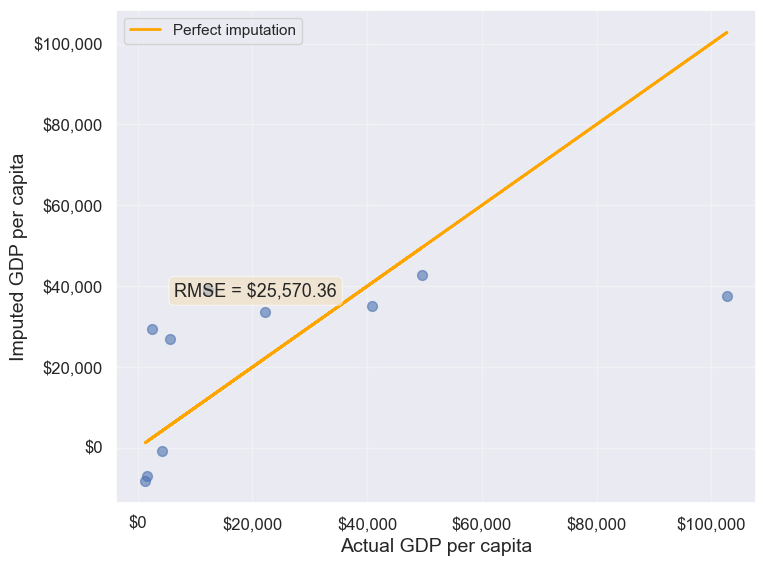

25570.361516956993

In [27]:
plot_actual_vs_predicted(gdp_imputed_data_lr)

##### C. K-Nearest Neighbors (KNN) Imputation

**Idea**: Impute missing values using the **mean of K most similar observations** (nearest neighbors).

KNN finds observations that are "similar" based on Euclidean distance calculated from other variables. This method is more sophisticated and often produces better results than simple mean imputation because it considers the overall similarity between observations.

In this method, we'll impute the missing value of the variable as the mean value of the $K$-nearest neighbors having non-missing values for that variable. The neighbors to a data-point are identified based on their Euclidean distance to the point in terms of the standardized values of rest of the variables in the data.

Let's consider a toy example to understand missing value imputation by KNN. Suppose we have to impute missing values in a toy dataset, named as `toy_data` having 4 observations and 3 variables.

In [28]:
#Toy example - A 4x3 array with missing values
nan = np.nan
toy_data = np.array([[1, 2, nan], [3, 4, 3], [nan, 6, 5], [8, 8, 7]])
toy_data

array([[ 1.,  2., nan],
       [ 3.,  4.,  3.],
       [nan,  6.,  5.],
       [ 8.,  8.,  7.]])

We'll use some functions from the *sklearn* library to perform the KNN imputation. It is much easier to directly use the algorithm from *sklearn*, instead of coding it from scratch.

In [29]:
#Library to compute pair-wise Euclidean distance between all observations in the data
from sklearn import metrics

#Library to impute missing values with the KNN algorithm
from sklearn import impute

We'll use the *sklearn* function [nan_euclidean_distances()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.nan_euclidean_distances.html) to compute the Euclidean distance between all pairs of observations in the data.

In [30]:
#This is the distance matrix containing the distance of the ith observation from the jth observation at the (i,j) position in the matrix
metrics.pairwise.nan_euclidean_distances(toy_data,toy_data)

array([[ 0.        ,  3.46410162,  6.92820323, 11.29158979],
       [ 3.46410162,  0.        ,  3.46410162,  7.54983444],
       [ 6.92820323,  3.46410162,  0.        ,  3.46410162],
       [11.29158979,  7.54983444,  3.46410162,  0.        ]])

Note that the size of the above matrix is 4x4. This is because the $(i,j)^{th}$ element of the matrix is the distance of the $i^{th}$ observation from the $j^{th}$ observation. The matrix is symmetric because the distance of $i^{th}$ observation to the $j^{th}$ observation is the same as the distance of the $j^{th}$ observation to the $i^{th}$ observation.

We'll use the *sklearn* function [KNNImputer()](https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html) to impute the missing value of a column in `toy_data` as the mean of the values of the $K$ nearest neighbors to the observation that have non-missing values for that column.

Let us impute the missing values in `toy_data` using the values of $K=2$ nearest neighbors from the corresponding observation.

In [31]:
#imputing missing values with 2 nearest neighbors, where the neighbors have equal weights

#Define an object of type KNNImputer
imputer = impute.KNNImputer(n_neighbors=2)

#Use the object method 'fit_transform' to impute missing values
imputer.fit_transform(toy_data)

array([[1. , 2. , 4. ],
       [3. , 4. , 3. ],
       [5.5, 6. , 5. ],
       [8. , 8. , 7. ]])

The third observation was the closest to the $2nd$ and $4th$ observations based on the Euclidean distance matrix. Thus, the missing value in the $3rd$ row of the `toy_data` has been imputed as the mean of the values in the $2nd$ and $4th$ observations for the corresponding column. Similarly, the $1st$ observation is the closest to the $2nd$ and $3rd$ observations. Thus the missing value in the $1st$ row of `toy_data` has been imputed as the mean of the values in the $1st$ and $2nd$ observations for the corresponding column.

Let us use KNN to impute the missing values of `gdpPerCapita` in `gdp_missing_values_data`. We'll use only the numeric columns of the data in imputing the missing values. Also, we'll ignore `contraception` as it has a lot of missing values, and thus may not be useful.

In [32]:
#Considering numeric columns in the data to use KNN
num_cols = list(range(0,1))+list(range(2,9))
num_cols

[0, 2, 3, 4, 5, 6, 7, 8]

Before computing the pair-wise Euclidean distance of observations, we must standardize the data so that all columns are at the same scale. This will avoid columns with a higher magnitude of values having a higher weight in determining the Euclidean distance. Unless there is a reason to give a higher weight to a column, we assume all columns to have the same weight in the Euclidean distance computation.

We can use the code below to scale the data. However, after imputing the missing values, the data is to be scaled back to the original scale, so that each variable is in the same units as in the original dataset. However, if the code below is used, we'll lose the orginal scale of each of the columns.

In [33]:
#Scaling data to compute equally weighted distances from the 'k' nearest neighbors
scaled_data = gdp_missing_values_data.iloc[:,num_cols].apply(lambda x:(x-x.min())/(x.max()-x.min()))

To alleviate the problem of losing the orignial scale of the data, we'll use the [MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) object of the *sklearn* library. The object will store the original scale of the data, which will help transform the data back to the original scale once the missing values have been imputed in the standardized data.

In [34]:
# Scaling data - using sklearn

#Create an object of type MinMaxScaler
scaler = sk.preprocessing.MinMaxScaler()

#Use the object method 'fit_transform' to scale the values to a standard uniform distribution
scaled_data = pd.DataFrame(scaler.fit_transform(gdp_missing_values_data.iloc[:,num_cols]))

In [35]:
#Imputing missing values with KNNImputer

#Define an object of type KNNImputer
imputer = impute.KNNImputer(n_neighbors=3, weights="uniform")

#Use the object method 'fit_transform' to impute missing values
imputed_arr = imputer.fit_transform(scaled_data)

In [36]:
#Scaling back the scaled array to obtain the data at the original scale

#Use the object method 'inverse_transform' to scale back the values to the original scale of the data
unscaled_data = scaler.inverse_transform(imputed_arr)

In [37]:
#Note the method imputes the missing value of all the columns
#However, we are interested in imputing the missing values of only the 'gdpPerCapita' column
gdp_imputed_data_knn = gdp_missing_values_data.copy()
gdp_imputed_data_knn.loc[:,'gdpPerCapita'] = unscaled_data[:,3]

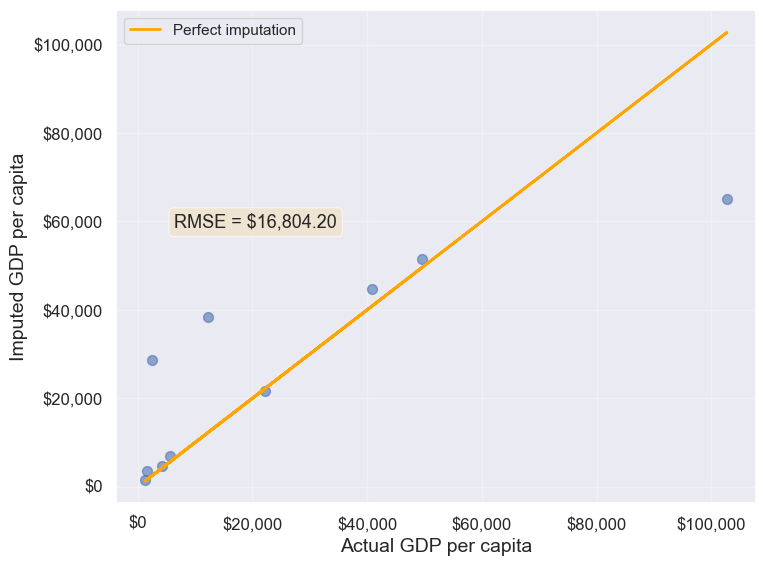

16804.195967740387

In [38]:
#Visualizing the accuracy of missing value imputation with KNN
plot_actual_vs_predicted(gdp_imputed_data_knn)

Note that the RMSE is the lowest in this method. It is because this method imputes missing values as the average of the values of "similar" observations, which is smarter and more robust than the previous methods.

We chose $K=3$ in the missing value imputation for GDP per capita. However, the value of $K$ is typically chosen using a method known as cross validation. We'll learn about cross-validation in the next course of the sequence.

#### Method 3: Forward Fill / Backward Fill

**Idea**: Fill missing values by propagating the **previous** (forward fill) or **next** (backward fill) non-missing value.

**When to use:**
- Time series data where values change gradually
- Data sorted in a meaningful order
- Assumes temporal or sequential dependency

**Limitations:**
- Inappropriate for cross-sectional data (like our GDP dataset)
- Assumes the missing value should be similar to adjacent observations
- Can introduce bias if data order is arbitrary

Let's demonstrate forward fill on our dataset (though it's not ideal for this use case):

In [39]:
#Filling missing values: Method 1- Naive way
gdp_imputed_data_ffill = gdp_missing_values_data.ffill()

Let us next check how good is this method in imputing missing values.

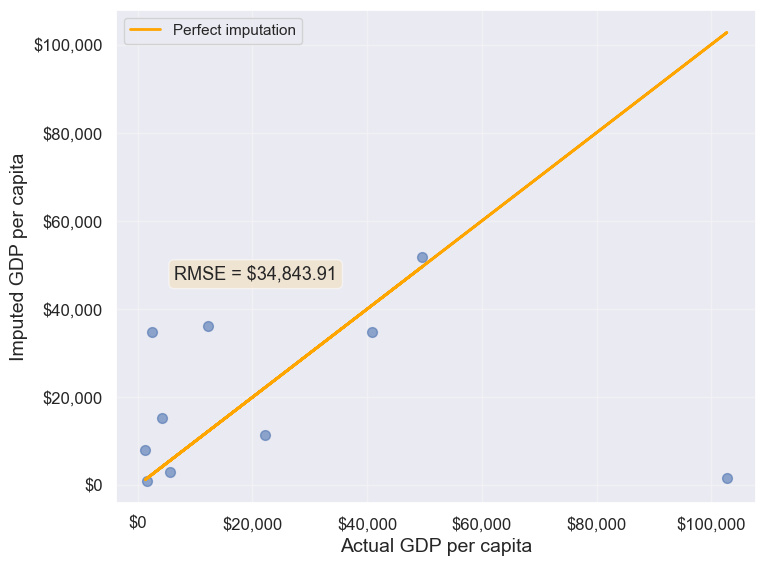

34843.91091137732

In [40]:
plot_actual_vs_predicted(gdp_imputed_data_ffill)

We observe that the accuracy of imputation is poor as GDP per capita can vary a lot across countries, and the data is not sorted by GDP per capita. There is no reason why the GDP per capita of a country should be close to the GDP per capita of the country in the observation above it.

In [41]:
#Checking if any missing values are remaining
gdp_imputed_data_ffill.isnull().sum()

economicActivityFemale    0
country                   0
lifeMale                  0
infantMortality           0
gdpPerCapita              0
economicActivityMale      0
illiteracyMale            1
illiteracyFemale          0
lifeFemale                0
geographic_location       0
continent                 0
dtype: int64

After imputing missing values, note there is still one missing value for *illiteracyMale*. Can you guess why one missing value remained?

## Dealing with Duplicate Records

Duplicate records can occur in datasets for various reasons:
- Data entry errors (same record entered multiple times)
- Merging datasets from different sources
- System errors during data collection
- Intentional duplicates that need investigation

Fortunately, detecting and removing duplicates is relatively straightforward in pandas. Let's explore the methods for identifying and handling duplicate records.

### Creating a Sample Dataset with Duplicates

First, let's manually create a dataset that contains duplicate records to demonstrate the various duplicate detection and removal techniques.

In [43]:
# Create a sample dataframe with duplicate records
student_data = pd.DataFrame({
    'StudentID': [101, 102, 103, 101, 104, 102, 105, 103],
    'Name': ['Alice', 'Bob', 'Charlie', 'Alice', 'David', 'Bob', 'Eve', 'Charlie'],
    'Major': ['CS', 'Math', 'CS', 'CS', 'Physics', 'Math', 'Biology', 'CS'],
    'GPA': [3.8, 3.5, 3.9, 3.8, 3.7, 3.5, 3.6, 3.9]
})

print("Original dataset with duplicates:")
student_data

Original dataset with duplicates:


,StudentID,Name,Major,GPA
0,101,Alice,CS,3.8
1,102,Bob,Math,3.5
2,103,Charlie,CS,3.9
3,101,Alice,CS,3.8
4,104,David,Physics,3.7
5,102,Bob,Math,3.5
6,105,Eve,Biology,3.6
7,103,Charlie,CS,3.9


### Identifying Duplicate Records

There are several ways to identify duplicates in a DataFrame:

####  Check How Many Duplicate Rows Exist

The `duplicated()` method returns a boolean Series indicating whether each row is a duplicate. We can sum this to count the total number of duplicate rows.

In [44]:
# Count the number of duplicate rows
num_duplicates = student_data.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

# Check which rows are duplicates (returns boolean Series)
print("\nDuplicate flags for each row:")
student_data.duplicated()

Number of duplicate rows: 3

Duplicate flags for each row:


0    False
1    False
2    False
3     True
4    False
5     True
6    False
7     True
dtype: bool

**Note:** By default, `duplicated()` marks all duplicate rows as `True` **except the first occurrence**. So if a row appears 3 times, the first occurrence is marked `False` and the next 2 are marked `True`.

####  Display the Duplicated Rows

To see the actual duplicate records, we can filter the DataFrame using the boolean mask returned by `duplicated()`.

In [45]:
# Display the duplicate rows (excluding the first occurrence)
print("Duplicate rows:")
student_data[student_data.duplicated()]

Duplicate rows:


,StudentID,Name,Major,GPA
3,101,Alice,CS,3.8
5,102,Bob,Math,3.5
7,103,Charlie,CS,3.9


To see **all occurrences** of duplicate rows (including the first occurrence), use `keep=False`:

In [46]:
# Display ALL occurrences of duplicate rows (including first occurrence)
print("All occurrences of duplicate rows:")
student_data[student_data.duplicated(keep=False)]

All occurrences of duplicate rows:


,StudentID,Name,Major,GPA
0,101,Alice,CS,3.8
1,102,Bob,Math,3.5
2,103,Charlie,CS,3.9
3,101,Alice,CS,3.8
5,102,Bob,Math,3.5
7,103,Charlie,CS,3.9


####  Check Duplicates Based on Specific Columns

Sometimes you want to identify duplicates based on only certain columns, not all columns. For example, you might consider two students duplicates if they have the same `StudentID`, even if other details differ.

In [47]:
# Check duplicates based on StudentID only
print("Duplicates based on StudentID:")
print(f"Number of duplicate StudentIDs: {student_data.duplicated(subset=['StudentID']).sum()}")

print("\nRows with duplicate StudentID:")
student_data[student_data.duplicated(subset=['StudentID'], keep=False)]

Duplicates based on StudentID:
Number of duplicate StudentIDs: 3

Rows with duplicate StudentID:


,StudentID,Name,Major,GPA
0,101,Alice,CS,3.8
1,102,Bob,Math,3.5
2,103,Charlie,CS,3.9
3,101,Alice,CS,3.8
5,102,Bob,Math,3.5
7,103,Charlie,CS,3.9


In [48]:
# Check duplicates based on multiple columns (Name and Major)
print("Duplicates based on Name and Major:")
print(f"Number of duplicate Name-Major combinations: {student_data.duplicated(subset=['Name', 'Major']).sum()}")

print("\nRows with duplicate Name-Major combinations:")
student_data[student_data.duplicated(subset=['Name', 'Major'], keep=False)]

Duplicates based on Name and Major:
Number of duplicate Name-Major combinations: 3

Rows with duplicate Name-Major combinations:


,StudentID,Name,Major,GPA
0,101,Alice,CS,3.8
1,102,Bob,Math,3.5
2,103,Charlie,CS,3.9
3,101,Alice,CS,3.8
5,102,Bob,Math,3.5
7,103,Charlie,CS,3.9


### Removing Duplicate Records

Once duplicates are identified, we can remove them using the `drop_duplicates()` method.

####  Remove All Duplicated Rows

By default, `drop_duplicates()` keeps the **first occurrence** and removes subsequent duplicates.

In [ ]:
# Remove all duplicate rows (keeps first occurrence)
student_data_cleaned = student_data.drop_duplicates()

print("Dataset after removing duplicates:")
print(student_data_cleaned)

print(f"\nOriginal dataset size: {len(student_data)} rows")
print(f"Cleaned dataset size: {len(student_data_cleaned)} rows")
print(f"Removed: {len(student_data) - len(student_data_cleaned)} duplicate rows")

####  Remove Duplicates Based on Specific Columns

You can specify which columns to consider when identifying duplicates using the `subset` parameter.

In [ ]:
# Remove duplicates based on StudentID only
student_data_unique_id = student_data.drop_duplicates(subset=['StudentID'])

print("Dataset after removing duplicates based on StudentID:")
print(student_data_unique_id)

print(f"\nOriginal dataset: {len(student_data)} rows")
print(f"After removing duplicate StudentIDs: {len(student_data_unique_id)} rows")

In [ ]:
# Remove duplicates based on Name and Major
student_data_unique_name_major = student_data.drop_duplicates(subset=['Name', 'Major'])

print("Dataset after removing duplicates based on Name and Major:")
print(student_data_unique_name_major)

print(f"\nOriginal dataset: {len(student_data)} rows")
print(f"After removing duplicate Name-Major combinations: {len(student_data_unique_name_major)} rows")

####  Keep First or Last Occurrence

The `keep` parameter controls which occurrence to keep:
- `keep='first'` *(default)*: Keep the first occurrence, remove subsequent duplicates
- `keep='last'`: Keep the last occurrence, remove earlier duplicates
- `keep=False`: Remove all duplicates (including all occurrences)

In [ ]:
# Keep the first occurrence (default behavior)
keep_first = student_data.drop_duplicates(keep='first')
print("Keep first occurrence:")
print(keep_first)
print()

In [ ]:
# Keep the last occurrence
keep_last = student_data.drop_duplicates(keep='last')
print("Keep last occurrence:")
print(keep_last)
print()

In [ ]:
# Remove ALL occurrences of duplicates (keep none)
keep_none = student_data.drop_duplicates(keep=False)
print("Remove all occurrences of duplicates:")
print(keep_none)

print(f"\nOriginal dataset: {len(student_data)} rows")
print(f"After removing ALL duplicate occurrences: {len(keep_none)} rows")
print("Note: Only rows that appear exactly once are kept!")

### Applying to Real Data

Now let's check for duplicates in our GDP dataset:

In [50]:
# Check for duplicate records in GDP dataset
num_duplicates_gdp = gdp_imputed_data_ffill.duplicated().sum()
print(f"Number of duplicate rows in GDP dataset: {num_duplicates_gdp}")

if num_duplicates_gdp > 0:
    print("\nDuplicate rows:")
    print(gdp_imputed_data_ffill[gdp_imputed_data_ffill.duplicated(keep=False)])
else:
    print("\nNo duplicate records found in the GDP dataset!")

Number of duplicate rows in GDP dataset: 0

No duplicate records found in the GDP dataset!


If the dataset had duplicates, we could remove them using:

```python
# Remove duplicate records (if they existed)
gdp_imputed_data_ffill = gdp_imputed_data_ffill.drop_duplicates()
```

**Summary:**
- Use `duplicated()` to identify duplicate rows
- Use `drop_duplicates()` to remove them
- The `subset` parameter lets you specify which columns to check
- The `keep` parameter controls which occurrence to keep ('first', 'last', or False to remove all)

## Outlier detection and handling 

An outlier is an observation that is significantly different from the rest of the data. Outlier detection and handling are important in data science because outliers can significantly impact the quality, accuracy, and interpretability of data analysis and model performance. Here are the main reasons why it's crucial to address outliers:

* **Preventing Skewed Results:** Outliers can distort statistical measures, such as the mean and standard deviation, leading to misleading interpretations of the data. For example, a few extreme values can inflate the mean, making the data seem larger than it is in reality.
* **Improving Model Accuracy:** Many machine learning algorithms are sensitive to outliers and can perform poorly if outliers are present. For instance, in linear regression, outliers can disproportionately affect the model by pulling the line of best fit toward them, reducing predictive accuracy.
* **Enhancing Robustness of Models:** Identifying and handling outliers can make models more robust and stable. By minimizing the influence of extreme values, models become less sensitive to noise, which improves generalization and reduces overfitting.

### Outlier detection


Outlier detection is crucial for identifying unusual values in your data that may need to be investigated, removed, or transformed. Here are several popular methods for detecting outliers:

We will use  *College.csv* that contains information about US universities as our dataset in this section. The description of variables of the dataset can be found on page 65 of this [book](https://www.statlearning.com/resources-python).

In [53]:
# Load the College dataset
college = pd.read_csv('./Datasets/College.csv')
college.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


#### Visualization Methods

* **Box Plot**: A box plot is a quick and visual way to detect outliers, where points outside the "whiskers" are considered outliers.



Let us visualize outliers in average instructional expenditure per student given by the variable `Expend`.

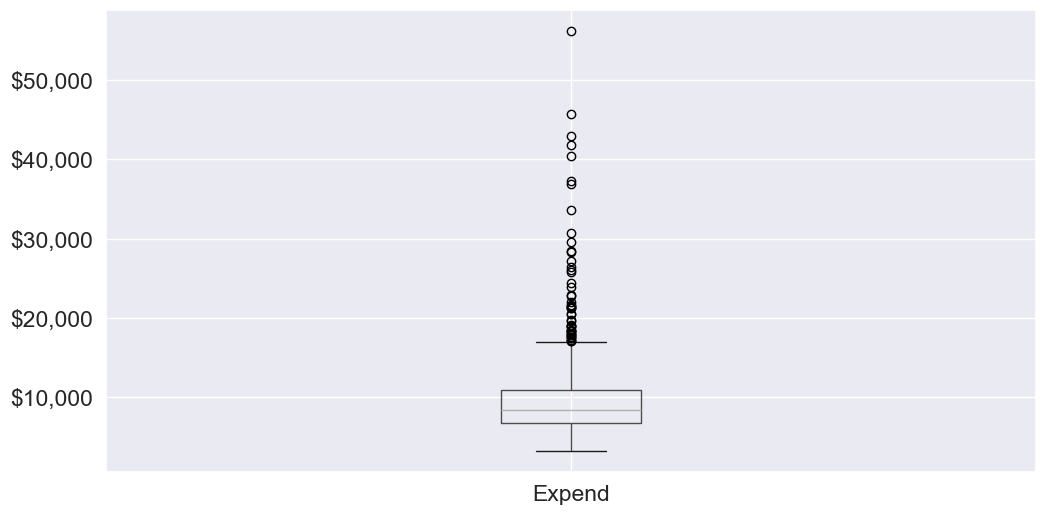

In [54]:
ax=college.boxplot(column = 'Expend')
ax.yaxis.set_major_formatter('${x:,.0f}')

There are several outliers (shown as circles in the above boxplot), which correspond to high values of average instructional expenditure per student.


* **Histogram**: Histograms can reveal unusual values as isolated bars, helping to identify outliers in a single feature.

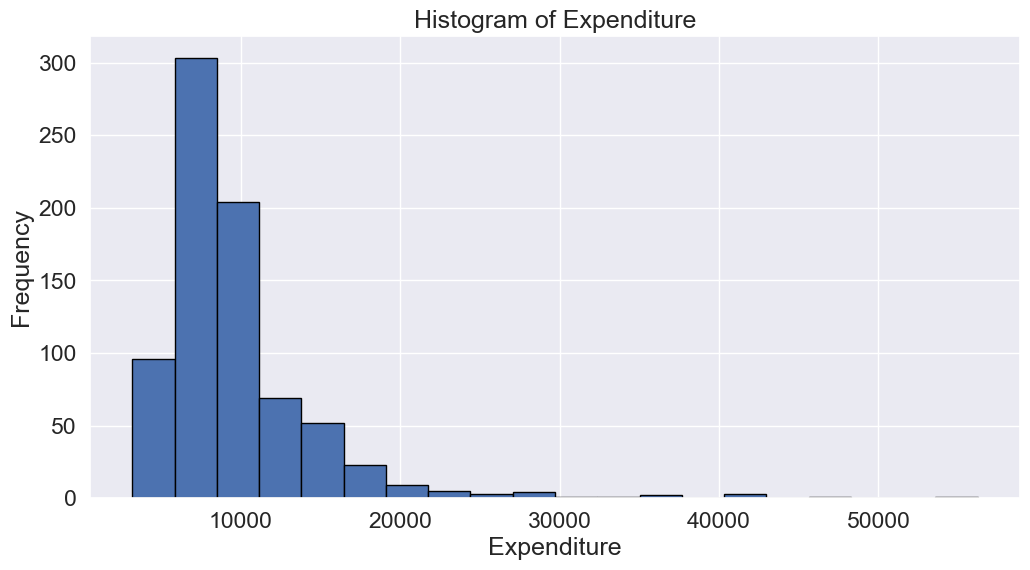

In [55]:
# create a histogram of expend
college['Expend'].plot(kind='hist', edgecolor='black', bins=20)
plt.xlabel('Expenditure')
plt.ylabel('Frequency')
plt.title('Histogram of Expenditure')
plt.show()

* **Scatter Plot**: A scatter plot can reveal outliers, especially in two-dimensional data. Outliers will often appear as points separated from the main cluster.

Let's make a scatterplot of 'Grad.Rate' vs 'Expend' with a trendline, to visualize potential outliers

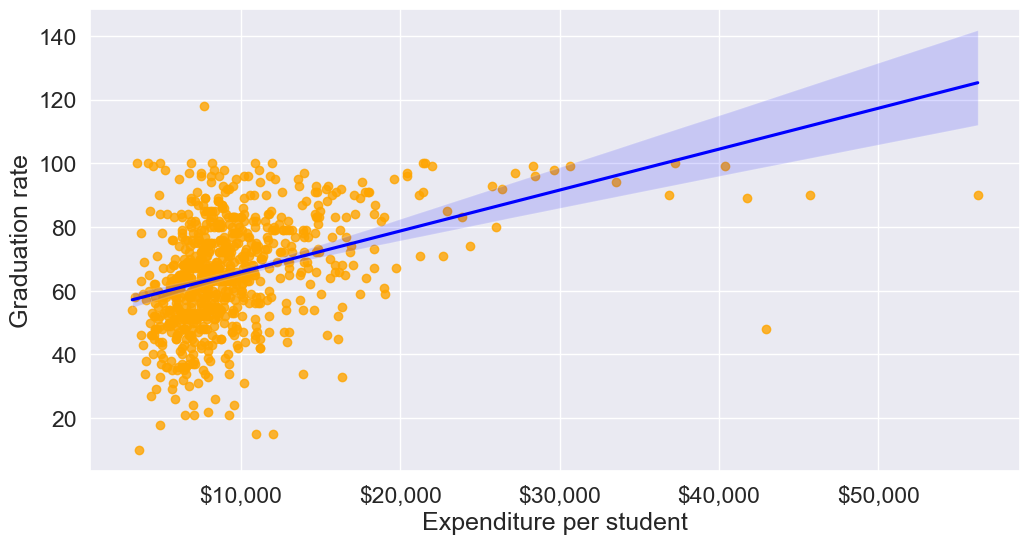

In [56]:
sns.set(font_scale=1.5)
ax=sns.regplot(data = college, x = "Expend", y = "Grad.Rate",scatter_kws={"color": "orange"}, line_kws={"color": "blue"})
ax.xaxis.set_major_formatter('${x:,.0f}')
ax.set_xlabel('Expenditure per student')
ax.set_ylabel('Graduation rate')
plt.show()

The trendline indicates a positive correlation between `Expend` and `Grad.Rate`. However, there seems to be a lot of noise and presence of outliers in the data.

#### Statistical Methods

Visualization helps us identify potential outliers. To address them effectively, we need to extract these outlier instances using a defined threshold. Two commonly used statistical methods for this purpose are the Z-Score method and the Interquartile Range (IQR) (Tukey's fences).

##### Z-Score (Standard Score)

Calculates how many standard deviations a data point is from the mean. Commonly, data points with a Z-score greater than 3 (or less than -3) are considered outliers.

In [57]:
from scipy import stats

# Calculate Z-scores and identify outliers
college['z_score'] = stats.zscore(college['Expend'])
college['is_z_score_outlier'] = college['z_score'].abs() > 3

# Filter to show only the outliers
z_score_outliers = college[college['is_z_score_outlier']]
print(z_score_outliers.shape)
z_score_outliers.head()

(16, 21)


,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,z_score,is_z_score_outlier
20,Antioch University,Yes,713,661,252,25,44,712,23,15476,...,400,1100,69,82,11.3,35,42926,48,6.374709,True
144,Columbia University,Yes,6756,1930,871,78,96,3376,55,18624,...,550,300,97,98,5.9,21,30639,99,4.020159,True
158,Dartmouth College,Yes,8587,2273,1087,87,99,3918,32,19545,...,550,1100,95,99,4.7,49,29619,98,3.824698,True
174,Duke University,Yes,13789,3893,1583,90,98,6188,53,18590,...,625,1162,95,96,5.0,44,27206,97,3.362296,True
191,Emory University,Yes,8506,4168,1236,76,97,5544,192,17600,...,600,870,97,98,5.0,28,28457,96,3.602024,True


 Boxplot identifies outliers based on the [Tukey's fences](https://en.wikipedia.org/wiki/Outlier) criterion:

##### IQR method (Tukey's fences)
John Tukey proposed that observations outside the range $[Q1 - 1.5(Q3-Q1), Q3+1.5(Q3-Q1)]$ are outliers, where $Q1$ and $Q3$ are the lower $(25\%)$ and upper $(75\%)$ quartiles respectively. Let us detect outliers based on this threshold.

In [58]:
# Calculate the first and third quartiles, and the IQR
Q1 = np.percentile(college['Expend'], 25)
Q3 = np.percentile(college['Expend'], 75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Add a new column to indicate IQR outliers
college['is_IQR_outlier'] = (college['Expend'] < lower_bound) | (college['Expend'] > upper_bound)

# Filter to show only the IQR outliers
iqr_outliers = college[college['is_IQR_outlier']]
print(iqr_outliers.shape)
iqr_outliers.head()

(48, 22)


,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,z_score,is_z_score_outlier,is_IQR_outlier
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,875,92,97,7.7,37,19016,59,1.792851,False,True
16,Amherst College,Yes,4302,992,418,83,96,1593,5,19760,...,1598,93,98,8.4,63,21424,100,2.254295,False,True
20,Antioch University,Yes,713,661,252,25,44,712,23,15476,...,1100,69,82,11.3,35,42926,48,6.374709,True,True
60,Bowdoin College,Yes,3356,1019,418,76,100,1490,8,19030,...,875,93,96,11.2,52,20447,96,2.067073,False,True
64,Brandeis University,Yes,4186,2743,740,48,77,2819,62,19380,...,1000,90,97,9.8,24,17150,84,1.435271,False,True


Using the IQR method, more instances in the college dataset are marked as outliers.

##### When to use each:

* Use IQR when:

  - Data is skewed
  - You don't want to assume any distribution
  - You want a more sensitive detector


* Use Z-score when:

  - Data is approximately normal
  - You want a more conservative approach
  - You need a method that's easily interpretable


The actual number of outliers marked by each method will depend on your specific dataset's distribution and characteristics.


### Common Methods for Handling outliers

Once we identify outlier instances using statistical methods, the next step is to handle them. Below are some commonly used approaches:

* **Removing Outliers**: Discarding extreme values if they are likely due to errors or are irrelevant for the analysis.
* **Winsorizing**: Capping/flooring outliers to a specific percentile to reduce their influence without removing them completely.
* **Replacing with the median**: Replacing outlier values with the median of the remaining data. The median is less affected by extreme values than the mean, making it an ideal choice for imputation when dealing with outliers
* **Transforming Data**: Applying transformations (e.g., log, square root) to reduce the impact of outliers.



In [59]:
def method_removal():
    """Method 1: Remove outliers"""
    data_cleaned = college[~college['is_outlier']]['Expend']
    return data_cleaned

In [60]:
def method_capping():
    """Method 2: Capping (Winsorization)"""
    data_capped = college['Expend'].copy()
    data_capped[data_capped < lower_bound] = lower_bound
    data_capped[data_capped > upper_bound] = upper_bound
    return data_capped

In [61]:
def method_mean_replacement():
    """Method 3: Replace with median"""
    data_median = college['Expend'].copy()
    median_value = college[~college['is_outlier']]['Expend'].median()
    data_median[college['is_outlier']] = median_value
    return data_median

In [62]:
def method_log_transformation():
    """Method 4: Log transformation"""
    data_log = np.log1p(college['Expend'])
    return data_log


**Your Practice:** Try each method and compare their results to see how they differ in handling outliers.

In real-world applications, handling outliers should be approached on a case-by-case basis. However, here are some general recommendations:

**Recommendations for Different Scenarios:**

 * Data Removal:
    - Use when: You have a large dataset and can afford to lose data
    - Pros: Simple, removes all outlier influence
    - Cons: Loss of data, potential loss of important information

* Capping (Winsorization):
   - Use when: You want to preserve data count while limiting extreme values
   - Pros: Preserves data size, reduces impact of outliers
   - Cons: Artificial boundary creation, potential loss of genuine extreme events

* Median Replacement:
   - Use when:  The data is normally distributed, and outliers are verified as errors or anomalies not representing true values
   - Pros: Maintains data size, simple to implement
   - Cons: Reduces variance, may not represent the true distribution

* Log Transformation:

   - Use when: Data has a right-skewed distribution, and you want to reduce the impact of large outliers.
   - Pros: Reduces skewness, minimizes the effect of extreme values, can make data more normal-like.
   - Cons: Only applicable to positive values, may not be effective for extremely high outliers.

## Independent Study

### Exercise 1: Missing Value Imputation Comparison

Using the *GDP_missing_data.csv* dataset:

1. Compare the RMSE for imputing missing `lifeFemale` values using:
   - Mean imputation
   - Median imputation
   - Regression with the most correlated variable
   - KNN imputation (k=3)

2. Which method performs best? Why do you think this is the case?

3. How does the choice of imputation method affect the distribution of the `lifeFemale` variable? Create histograms to visualize the differences.

### Exercise 2: Outlier Detection and Impact Analysis

Using the *College.csv* dataset:

1. Identify outliers in the `Grad.Rate` column using both Z-score and IQR methods.

2. How many outliers are identified by each method? Which method is more conservative?

3. Apply three different outlier handling methods (removal, capping, median replacement) to the `Grad.Rate` column.

4. For each method, calculate:
   - The mean graduation rate before and after handling outliers
   - The standard deviation before and after
   - Create box plots to visualize the differences

5. Which outlier handling method would you recommend for this dataset and why? Consider the context of graduation rates when making your decision.

### Exercise 3: Combined Data Cleaning Pipeline

Using the *GDP_missing_data.csv* dataset:

1. Create a comprehensive data cleaning pipeline that:
   - Removes columns with more than 40% missing values
   - Identifies the type of missing data (MCAR, MAR, or MNAR) for each remaining column with missing values
   - Applies appropriate imputation methods based on the missing data type
   - Detects outliers in all numeric columns using the IQR method
   - Handles outliers using an appropriate strategy

2. Document your decisions at each step with justifications.

3. Compare key statistics (mean, median, standard deviation) before and after your cleaning pipeline.

4. Create a summary report showing:
   - Number of missing values handled
   - Number of outliers detected and handled
   - RMSE for your imputation methods (where applicable)
   - Visual comparisons (scatter plots or box plots) showing the impact of your cleaning steps